In [1303]:

import astropy.units as u

R = 8.314472 * u.J / (u.mol * u.K)
T_init = 273.15 * u.K
P_init = 264.96 * u.Pa
N_A = 6.022140e23  / u.mol
n = (P_init * N_A / (R * T_init)).to(u.m**-3)

k_B = 1.380658e-23 * u.m**2 * u.kg / (u.s**2 * u.K)
n_2 = (P_init / (k_B * T_init)).to(u.m**-3)

print(n)
print(n_2)

7.025791910216458e+22 1 / m3
7.025754926017738e+22 1 / m3


In [1304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1305]:
# parameters for hard sphere interactions
omega = 0.5
# corresponds to isotropic scattering
alpha = 1
mu_inf_mu_1 = 1.016034
mu_1_mu_inf =  1 / mu_inf_mu_1
mu_ref = 2.117e-5

m = 66.3e-27

k_B = 1.380658e-23
T_init = 273.15
numerator =  5 * (alpha + 1) * (alpha + 2) * np.sqrt(m * k_B * T_init / np.pi)
denominator = 4 * alpha * (5 - 2 * omega) * (7 - 2 * omega) * mu_ref * (mu_1_mu_inf)
d_ref =  np.sqrt(numerator / denominator)
print(f"Reference Diameter : {d_ref:0.4E}")
pressure = 264.96
N_A = 6.022140e23
R = 8.314472
density = pressure * N_A / (R * T_init)
lambda_0 =  1 / (np.sqrt(2) * np.pi * d_ref**2 * density)
print(f"Lambda_0           : {lambda_0:0.4E}")

L = 1e-3
cell_counts = 200
dx = L / cell_counts
dx_tilde = dx / lambda_0
print(f"Delta x tilde      : {dx_tilde:0.4E}")

c_0 = np.sqrt(2 * k_B * T_init / m)
print(f"c_0                : {c_0:0.4E}")
dt = 5e-8
t_0 = lambda_0 / c_0

dt_tilde = dt / t_0
print(f"Delta t tilde      : {dt_tilde:0.4E}")

Reference Diameter : 3.6579E-10
Lambda_0           : 2.3943E-05
Delta x tilde      : 2.0883E-01
c_0                : 3.3729E+02
Delta t tilde      : 7.0436E-01


In [1306]:
def q_wall(dt_tilde, dx_tilde):
  factor = 1 + 0.0281 * dt_tilde**2
  factor += 0.0399 * dx_tilde**2
  factor -= 0.0011 * dx_tilde**4
  factor -= 0.0170 * dt_tilde**2 * dx_tilde**2
  factor += 0.0083 * dt_tilde**4 * dx_tilde**2
  return 1512 * factor

expected_q_wall = q_wall(dt_tilde, dx_tilde)

In [1307]:
def trueSolution(x, T_mid, delta_T):
  T_min = T_mid - delta_T / 2.0
  return T_min + (delta_T) / (x.max() - x.min()) * x

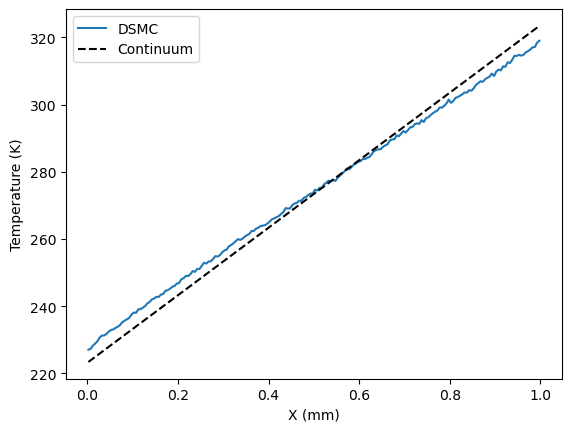

In [1308]:
temperature_data = pd.read_csv("real_csv_final_average_temperature_40001.csv")
plt.figure()
plt.plot(temperature_data["x"] * 1e3, temperature_data["time_averaged_temperature"], label="DSMC")
plt.plot(x_vals, trueSolution(x_vals, T_mid, delta_T), 'k--', label="Continuum" )
plt.legend()
plt.xlabel("X (mm)")
plt.ylabel("Temperature (K)")
plt.show()

20000.0


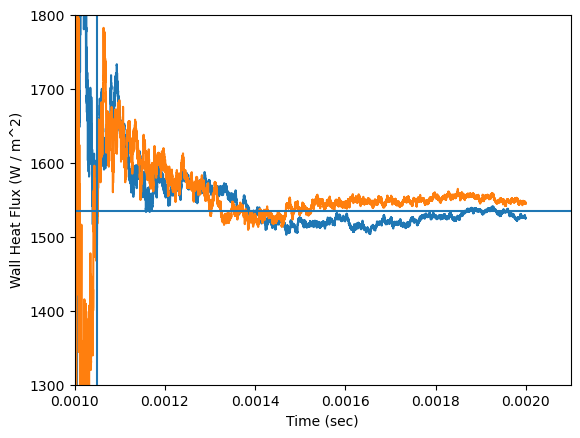

In [1309]:
data = pd.read_csv("real_csv.csv")
plt.figure()
plt.plot(data["time"], data["left_heat_flux"])
plt.plot(data["time"], np.abs(data["right_heat_flux"]))
plt.xlim(left=20000 * 5e-8)
plt.ylim(top=1800, bottom=1300)
print(0.001 / 5e-8)
plt.axvline(0.00105)
plt.axhline(expected_q_wall)
plt.xlabel("Time (sec)")
plt.ylabel("Wall Heat Flux (W / m^2)")
plt.show()

In [1310]:
heat_flux_left = data["left_heat_flux"].to_numpy()[-1]
heat_flux_right = data["right_heat_flux"].to_numpy()[-1]
heat_flux_mean = (heat_flux_left + np.abs(heat_flux_right)) / 2

print(f"Expected wall heat flux   : {expected_q_wall:0.2f} W / m^2")
print(f"Mean wall flux            : {heat_flux_mean:0.2f} W / m^2")
print(f"Mean wall flux error      : {np.abs(heat_flux_mean - expected_q_wall) / expected_q_wall * 100:0.2f} %")
print(f"Left wall heat flux       : {heat_flux_left:0.2f} W / m^2")
print(f"Left wall heat flux error : {np.abs(heat_flux_left - expected_q_wall) / expected_q_wall * 100:0.2f} %")
print(f"Right wall heat flux      : {np.abs(heat_flux_right):0.2f} W / m^2")
print(f"Left wall heat flux error : {np.abs(np.abs(heat_flux_right) - expected_q_wall) / expected_q_wall * 100:0.2f} %")
print(f"Wall Heat Flux Difference : {np.abs(heat_flux_left - np.abs(heat_flux_right) )/ heat_flux_mean * 100:0.2f} %")

Expected wall heat flux   : 1535.29 W / m^2
Mean wall flux            : 1535.90 W / m^2
Mean wall flux error      : 0.04 %
Left wall heat flux       : 1525.45 W / m^2
Left wall heat flux error : 0.64 %
Right wall heat flux      : 1546.36 W / m^2
Left wall heat flux error : 0.72 %
Wall Heat Flux Difference : 1.36 %
